In [ ]:
# =============================================================
# CGS 410 Final Project
# Cross-Linguistic Analysis of Syntactic Interveners
# Using Universal Dependencies (SUD) Treebanks
#
# This notebook:
#   1. Parses CoNLL-U treebank files for 12 typologically
#      diverse languages
#   2. Extracts all syntactic interveners (tokens between a
#      dependency head and its dependent)
#   3. Tests three hypotheses about what shapes intervener
#      POS distributions:
#        H1 — Head POS (VERB vs NOUN)
#        H2 — Dependency direction & word-order typology
#        H3 — Dependency distance
#   4. Reports chi-squared significance and Cramér's V effect
#      sizes for each hypothesis
# =============================================================

In [ ]:
# Mount Google Drive so that treebank files and output CSVs/
# plots can be read from and written to a persistent location.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# List the contents of the project data folder to verify all
# expected CoNLL-U files are present before processing begins.
import os

data_path = '/content/drive/MyDrive/cgs410-project/SUD'
files = os.listdir(data_path)
print(f"Found {len(files)} files:")
for f in sorted(files):
    print(" -", f)

Found 12 files:
 - ar_padt-ud-train.conllu
 - de_gsd-ud-train.conllu
 - en_ewt-ud-train.conllu
 - es_gsd-ud-train.conllu
 - eu_bdt-ud-train.conllu
 - fi_tdt-ud-train.conllu
 - grc_proiel-ud-train.conllu
 - hi_hdtb-ud-train.conllu
 - ja_gsd-ud-train.conllu
 - ru_syntagrus-ud-train.conllu
 - tr_boun-ud-train.conllu
 - zh_gsd-ud-train.conllu


In [ ]:
# CoNLL-U Parser ───────────────────────────────────
def parse_conllu(filepath):
    """
    Parse a CoNLL-U treebank file into a list of sentences.

    Each sentence is a list of token dicts with keys:
        id      — 1-based integer position in the sentence
        form    — surface word form
        upos    — Universal POS tag (column 4)
        head    — integer id of the syntactic head (0 = root)
        deprel  — dependency relation label

    Multi-word tokens (ids containing '-') and empty nodes
    (ids containing '.') are skipped because they do not
    correspond to real syntactic tokens.  Comment lines
    starting with '#' are also skipped.

    Parameters
    ----------
    filepath : str
        Absolute path to the .conllu file.

    Returns
    -------
    list[list[dict]]
        A list of sentences; each sentence is a list of token
        dicts as described above.
    """

    sentences = []
    current = []
    with open(filepath, encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            # Blank line marks the end of a sentence
            if line == '':
                if current:
                    sentences.append(current)
                    current = []
                continue

            # Skip CoNLL-U comment / metadata lines
            if line.startswith('#'):
                continue
            parts = line.split('\t')

            # A valid token line must have exactly 10 tab-separated fields
            if len(parts) != 10:
                continue
            token_id = parts[0]

            # Skip multi-word tokens (e.g. "1-2") and empty nodes (e.g. "1.1")
            if '-' in token_id or '.' in token_id:
                continue
            current.append({
                'id':     int(token_id),
                'form':   parts[1],
                'upos':   parts[3],
                'head':   int(parts[6]),
                'deprel': parts[7]
            })

    # Flush the last sentence if the file does not end with a blank line
    if current:
        sentences.append(current)
    return sentences

print("Parser ready ✓")

Parser ready ✓


In [ ]:
# Intervener Extractor ─────────────────────────────
def get_distance_bin(d):
    """
    Map a raw dependency distance to a coarse three-way bin.

    Bins are used for H3 (distance hypothesis) so that
    distance effects can be compared categorically across
    languages without being confounded by raw token counts.

    Parameters
    ----------
    d : int
        Dependency distance = |head_id − dependent_id|.

    Returns
    -------
    str
        One of 'short (2-3)', 'medium (4-6)', 'long (7+)'.
    """

    if d <= 3:
        return 'short (2-3)'
    elif d <= 6:
        return 'medium (4-6)'
    else:
        return 'long (7+)'

def get_interveners_enhanced(sentence):
    """
    Extract every intervening token for all non-adjacent
    dependency arcs in a sentence, annotated with features
    needed to test H1, H2, and H3.

    An 'intervener' is any token whose position falls strictly
    between the head and the dependent in linear order.
    Adjacent pairs (distance == 1) are skipped because they
    have no intervening positions.

    Root arcs (head_id == 0) and self-loops are also skipped.

    For each intervening token the following record is emitted:

        distance        — raw linear distance between head & dep
        distance_bin    — coarse distance bin (H3)
        direction       — 'head-left'  if head precedes dependent
                          'head-right' if dependent precedes head
                          (H2)
        head_upos       — Universal POS tag of the arc's head (H1)
        intervener_upos — Universal POS tag of the intervening token
        deprel          — dependency relation of the arc
        n_interveners   — total number of interveners on this arc

    Parameters
    ----------
    sentence : list[dict]
        A single parsed sentence (output of parse_conllu).

    Returns
    -------
    list[dict]
        One dict per (arc, intervening token) pair.
    """

    # Build a lookup table so we can access any token by its id in O(1)
    token_by_id = {t['id']: t for t in sentence}
    results = []

    for token in sentence:
        dep_id  = token['id']
        head_id = token['head']
        deprel  = token['deprel']

        # Skip root arcs and degenerate self-loops
        if head_id == 0 or head_id == dep_id:
            continue

        left     = min(dep_id, head_id)
        right    = max(dep_id, head_id)
        distance = right - left

        # Adjacent tokens share no intervening positions — skip
        if distance <= 1:
            continue

        # H2 feature: does the head appear before or after the dependent?
        direction = 'head-left' if head_id < dep_id else 'head-right'

        # H1 feature: POS of the arc's head token
        head_upos = token_by_id[head_id]['upos'] if head_id in token_by_id else 'UNK'

        # Collect the POS tags of all tokens that sit between head and dependent
        interveners = [
            token_by_id[i]['upos']
            for i in range(left + 1, right)
            if i in token_by_id
        ]

        # Emit one record per intervening token so each observation is
        # independently analysable (e.g. in groupby / crosstab operations)
        for pos in interveners:
            results.append({
                'distance':        distance,
                'distance_bin':    get_distance_bin(distance),   # NEW (H3)
                'direction':       direction,                     # NEW (H2)
                'head_upos':       head_upos,                    # NEW (H1)
                'intervener_upos': pos,
                'deprel':          deprel,
                'n_interveners':   len(interveners),
            })

    return results

print("Enhanced extractor ready ✓")

Enhanced extractor ready ✓


In [ ]:
# Build the Master DataFrame ───────────────────────
import pandas as pd

# Maps language name to the corresponding SUD CoNLL-U filename.
LANGUAGE_FILES = {
    'English':       'en_ewt-ud-train.conllu',
    'German':        'de_gsd-ud-train.conllu',
    'Spanish':       'es_gsd-ud-train.conllu',
    'Russian':       'ru_syntagrus-ud-train.conllu',
    'Arabic':        'ar_padt-ud-train.conllu',
    'Hindi':         'hi_hdtb-ud-train.conllu',
    'Turkish':       'tr_boun-ud-train.conllu',
    'Finnish':       'fi_tdt-ud-train.conllu',
    'Japanese':      'ja_gsd-ud-train.conllu',
    'Chinese':       'zh_gsd-ud-train.conllu',
    'Basque':        'eu_bdt-ud-train.conllu',
    'Ancient_Greek': 'grc_proiel-ud-train.conllu',
}

# Canonical word-order classification for each language.
# Used as a typological grouping variable in H2 plots.
WORD_ORDER_GROUP = {
    'English': 'SVO', 'German': 'SVO', 'Spanish': 'SVO',
    'Russian': 'SVO', 'Arabic': 'VSO', 'Hindi': 'SOV',
    'Turkish': 'SOV', 'Finnish': 'SVO', 'Japanese': 'SOV',
    'Chinese': 'SVO', 'Basque': 'SOV', 'Ancient_Greek': 'SOV',
}

all_records = []

# Iterate over all languages, parse the treebank, and extract
# intervener records.  Missing files are skipped with a warning
# so that partial runs still produce usable output.
for lang, filename in LANGUAGE_FILES.items():
    filepath = f'/content/drive/MyDrive/cgs410-project/SUD/{filename}'
    if not os.path.exists(filepath):
        print(f"⚠️  Not found: {filename} — skipping")
        continue
    print(f"Processing {lang}...", end=' ')
    sentences = parse_conllu(filepath)
    count = 0
    for sent in sentences:
        for record in get_interveners_enhanced(sent):
            # Tag each record with its source language and word-order group
            record['language']   = lang
            record['word_order'] = WORD_ORDER_GROUP.get(lang, 'Unknown')
            all_records.append(record)
            count += 1
    print(f"✓  ({len(sentences)} sentences, {count:,} intervener instances)")

# Consolidate all records into a single DataFrame for analysis
df = pd.DataFrame(all_records)

df.to_csv('/content/drive/MyDrive/cgs410-project/interveners_enhanced.csv', index=False)
print(f"\nTotal rows: {len(df):,}")
df.head()

Processing English... ✓  (12544 sentences, 455,203 intervener instances)
Processing German... ✓  (13813 sentences, 691,166 intervener instances)
Processing Spanish... ✓  (14187 sentences, 886,298 intervener instances)
Processing Russian... ✓  (24516 sentences, 913,822 intervener instances)
Processing Arabic... ✓  (6075 sentences, 686,958 intervener instances)
Processing Hindi... ✓  (13306 sentences, 680,436 intervener instances)
Processing Turkish... ✓  (7803 sentences, 176,762 intervener instances)
Processing Finnish... ✓  (12217 sentences, 316,306 intervener instances)
Processing Japanese... ✓  (7050 sentences, 293,324 intervener instances)
Processing Chinese... ✓  (3997 sentences, 282,394 intervener instances)
Processing Basque... ✓  (5396 sentences, 128,729 intervener instances)
Processing Ancient_Greek... ✓  (15016 sentences, 310,680 intervener instances)

Total rows: 5,822,078


,distance,distance_bin,direction,head_upos,intervener_upos,deprel,n_interveners,language,word_order
0,2,short (2-3),head-left,PROPN,PUNCT,flat,1,English,SVO
1,3,short (2-3),head-right,VERB,ADJ,punct,2,English,SVO
2,3,short (2-3),head-right,VERB,NOUN,punct,2,English,SVO
3,6,medium (4-6),head-left,PROPN,PUNCT,parataxis,5,English,SVO
4,6,medium (4-6),head-left,PROPN,PROPN,parataxis,5,English,SVO


In [ ]:
# Quick Descriptive Overview ───────────────────────
# Sanity-check the three key variables before plotting:
#   · overall POS distribution of interveners
#   · counts for head-left vs head-right dependencies
#   · counts across the three distance bins
print("=== POS Distribution of Interveners (Overall) ===")
print(df['intervener_upos'].value_counts(normalize=True).mul(100).round(2).to_string())

print("\n=== Direction counts ===")
print(df['direction'].value_counts().to_string())

print("\n=== Distance bin counts ===")
print(df['distance_bin'].value_counts().to_string())

=== POS Distribution of Interveners (Overall) ===
intervener_upos
NOUN     21.53
ADP      15.25
DET       8.78
ADJ       8.58
PUNCT     8.56
PROPN     6.77
VERB      5.18
PRON      4.48
CCONJ     4.32
ADV       4.17
AUX       4.02
NUM       2.70
PART      2.22
SCONJ     2.09
X         1.08
SYM       0.23
INTJ      0.03

=== Direction counts ===
direction
head-left     3517897
head-right    2304181

=== Distance bin counts ===
distance_bin
long (7+)       3759208
medium (4-6)    1065913
short (2-3)      996957


/tmp/ipykernel_820/207491602.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pos_freq.index, y=pos_freq.values, palette='viridis')


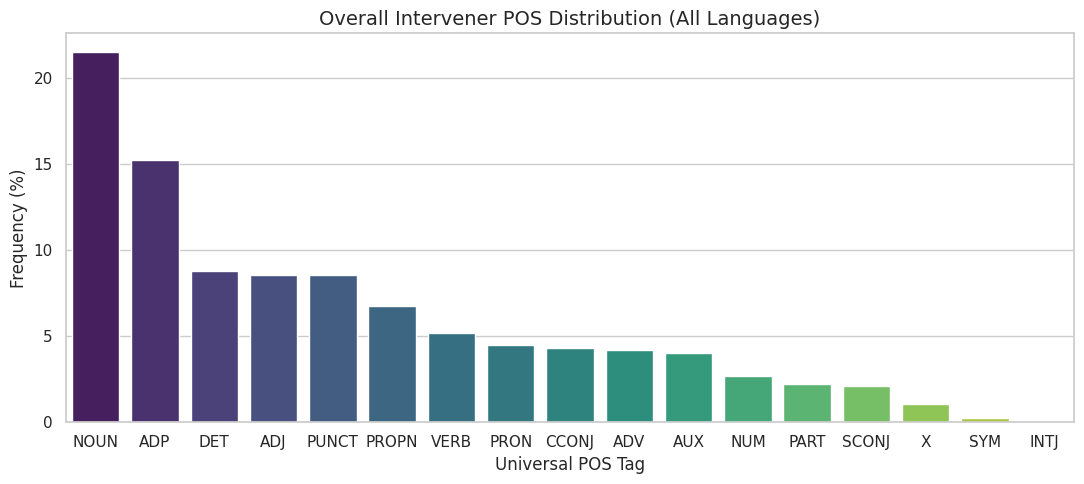

In [ ]:
# Plot 1 — Overall Intervener POS Distribution ─────
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')
os.makedirs('/content/drive/MyDrive/cgs410-project/plots', exist_ok=True)

# Aggregate POS frequencies as percentages across all languages
# to give a language-agnostic baseline for subsequent analyses.
pos_freq = df['intervener_upos'].value_counts(normalize=True) * 100

plt.figure(figsize=(11, 5))
sns.barplot(x=pos_freq.index, y=pos_freq.values, palette='viridis')
plt.title('Overall Intervener POS Distribution (All Languages)', fontsize=14)
plt.xlabel('Universal POS Tag')
plt.ylabel('Frequency (%)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cgs410-project/plots/plot1_overall_pos.png', dpi=150)
plt.show()

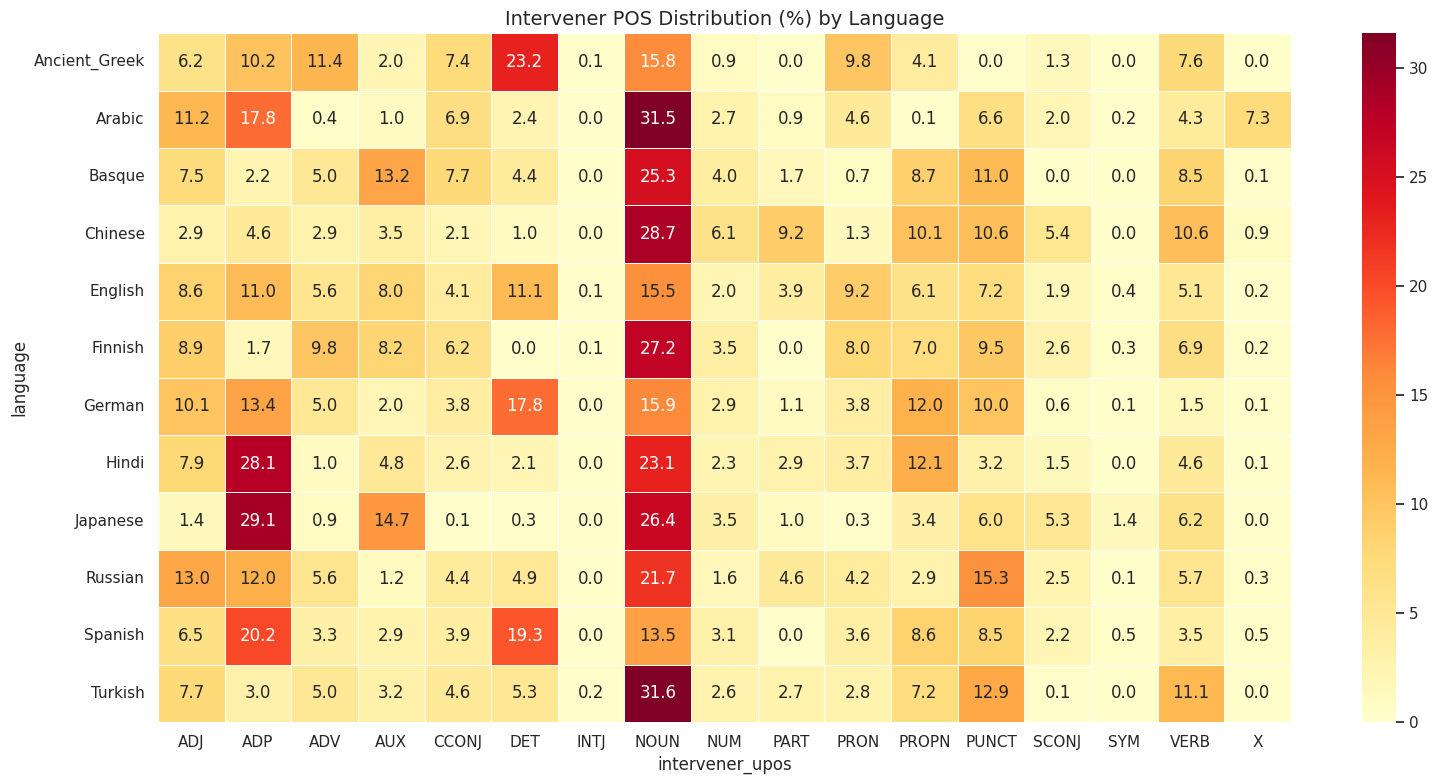

In [ ]:
# Plot 2 — Per-Language POS Heatmap ────────────────
# Compute within-language POS percentages and display as a
# heatmap.  This reveals which POS categories are universally
# common (NOUN, VERB, ADP) vs language-specific (DET, PART).
pos_by_lang = df.groupby(['language', 'intervener_upos']).size().reset_index(name='count')
pos_by_lang['percent'] = pos_by_lang.groupby('language')['count'].transform(
    lambda x: x / x.sum() * 100
)
pivot = pos_by_lang.pivot(index='language', columns='intervener_upos', values='percent').fillna(0)

plt.figure(figsize=(16, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Intervener POS Distribution (%) by Language', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cgs410-project/plots/plot2_heatmap.png', dpi=150)
plt.show()

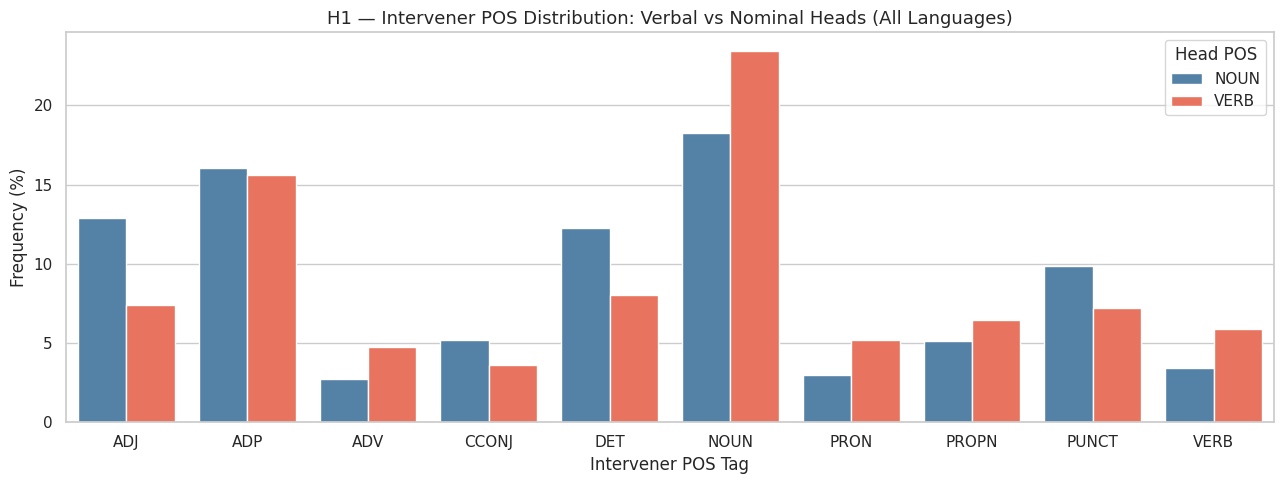

=== H1 Summary: Verbal vs Nominal Heads ===
head_upos         NOUN   VERB
intervener_upos              
ADJ              12.91   7.38
ADP              16.02  15.62
ADV               2.73   4.74
CCONJ             5.18   3.62
DET              12.25   8.04
NOUN             18.24  23.44
PRON              2.99   5.17
PROPN             5.15   6.48
PUNCT             9.86   7.21
VERB              3.42   5.88


In [ ]:
# Plot 3 — H1: Verbal vs Nominal Heads (Global) ────
# H1 predicts that verbal heads attract more functional/
# clausal interveners (AUX, SCONJ) while nominal heads attract
# more adjectival/determiner interveners (ADJ, DET).
# We restrict to the two most frequent and theoretically
# contrastive head categories: VERB and NOUN.

# Focus on the two most contrasting head types
head_focus = ['VERB', 'NOUN']
df_h1 = df[df['head_upos'].isin(head_focus)]

pos_by_head = df_h1.groupby(['head_upos', 'intervener_upos']).size().reset_index(name='count')
pos_by_head['percent'] = pos_by_head.groupby('head_upos')['count'].transform(
    lambda x: x / x.sum() * 100
)

# Keep top 10 intervener POS for clarity
top10 = df['intervener_upos'].value_counts().head(10).index.tolist()
plot_data = pos_by_head[pos_by_head['intervener_upos'].isin(top10)]

plt.figure(figsize=(13, 5))
sns.barplot(data=plot_data, x='intervener_upos', y='percent',
            hue='head_upos', palette={'VERB': 'tomato', 'NOUN': 'steelblue'})
plt.title('H1 — Intervener POS Distribution: Verbal vs Nominal Heads (All Languages)', fontsize=13)
plt.xlabel('Intervener POS Tag')
plt.ylabel('Frequency (%)')
plt.legend(title='Head POS')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cgs410-project/plots/plot3_H1_head_type.png', dpi=150)
plt.show()

# Print the key numbers
print("=== H1 Summary: Verbal vs Nominal Heads ===")
pivot_h1 = plot_data.pivot(index='intervener_upos', columns='head_upos', values='percent').round(2)
print(pivot_h1.to_string())

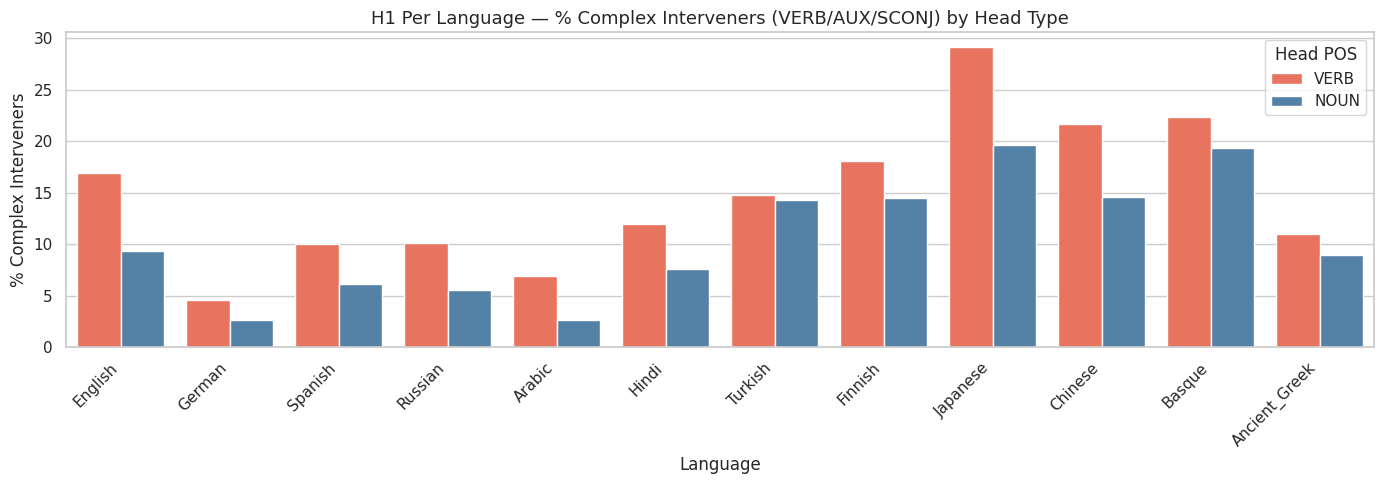

In [ ]:
# Plot 4 — H1 Per Language (Complex Interveners) ───
# 'Complex' interveners (VERB, AUX, SCONJ) signal embedded
# clausal material.  We expect verbal heads to show higher
# rates of complex interveners than nominal heads in all
# languages, since verbs more frequently take clausal complements
# and adverbial modifiers.

# For each language: VERB-headed vs NOUN-headed — what % of interveners are VERB/AUX/SCONJ (complex)?
complex_pos = ['VERB', 'AUX', 'SCONJ']

h1_lang = []
for lang in df['language'].unique():
    for head in ['VERB', 'NOUN']:
        sub = df[(df['language'] == lang) & (df['head_upos'] == head)]
        if len(sub) < 50:   # skip if too few examples
            continue
        pct_complex = sub['intervener_upos'].isin(complex_pos).mean() * 100
        h1_lang.append({'language': lang, 'head_upos': head, 'pct_complex': pct_complex})

h1_lang_df = pd.DataFrame(h1_lang)

plt.figure(figsize=(14, 5))
sns.barplot(data=h1_lang_df, x='language', y='pct_complex',
            hue='head_upos', palette={'VERB': 'tomato', 'NOUN': 'steelblue'})
plt.title('H1 Per Language — % Complex Interveners (VERB/AUX/SCONJ) by Head Type', fontsize=13)
plt.xlabel('Language')
plt.ylabel('% Complex Interveners')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Head POS')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cgs410-project/plots/plot4_H1_per_language.png', dpi=150)
plt.show()

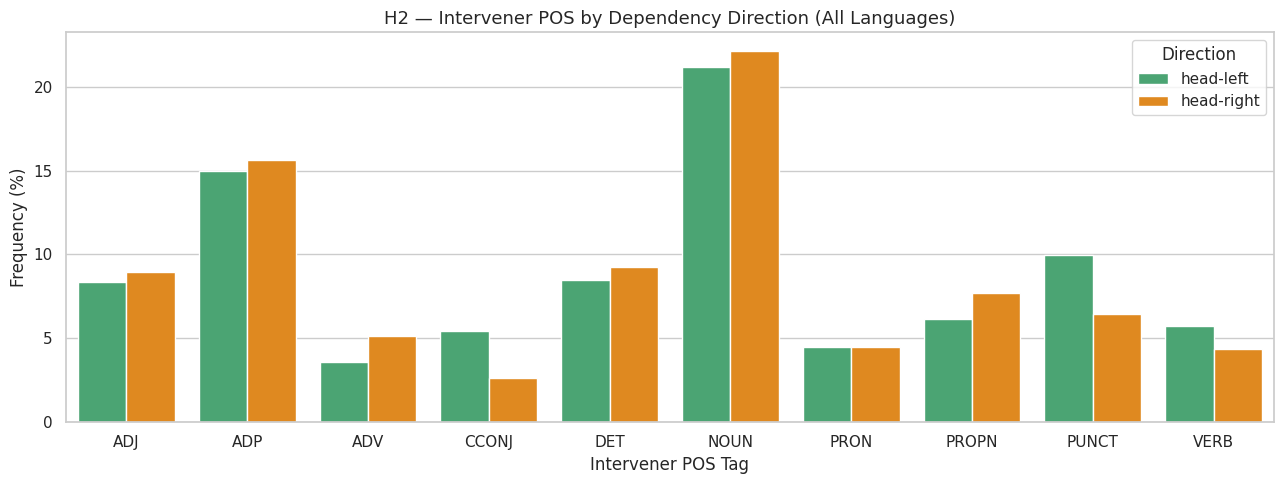

=== H2 Summary: Head-Left vs Head-Right ===
direction        head-left  head-right
intervener_upos                       
ADJ                   8.33        8.97
ADP                  15.00       15.64
ADV                   3.56        5.11
CCONJ                 5.44        2.61
DET                   8.46        9.27
NOUN                 21.14       22.13
PRON                  4.49        4.46
PROPN                 6.16        7.69
PUNCT                 9.94        6.46
VERB                  5.73        4.34


In [ ]:
# Plot 5 — H2: Direction (Head-Left vs Head-Right) ─
# H2 predicts that dependency direction co-varies with the
# type of intervener because right-branching structures
# (head-left, i.e. head precedes dependent) favour post-head
# functional words like ADP and SCONJ, while head-right
# structures favour pre-head modifiers like ADJ and DET.
pos_by_dir = df.groupby(['direction', 'intervener_upos']).size().reset_index(name='count')
pos_by_dir['percent'] = pos_by_dir.groupby('direction')['count'].transform(
    lambda x: x / x.sum() * 100
)

top10 = df['intervener_upos'].value_counts().head(10).index.tolist()
plot_data = pos_by_dir[pos_by_dir['intervener_upos'].isin(top10)]

plt.figure(figsize=(13, 5))
sns.barplot(data=plot_data, x='intervener_upos', y='percent',
            hue='direction', palette={'head-left': 'mediumseagreen', 'head-right': 'darkorange'})
plt.title('H2 — Intervener POS by Dependency Direction (All Languages)', fontsize=13)
plt.xlabel('Intervener POS Tag')
plt.ylabel('Frequency (%)')
plt.legend(title='Direction')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cgs410-project/plots/plot5_H2_direction.png', dpi=150)
plt.show()

# Print summary
pivot_h2 = plot_data.pivot(index='intervener_upos', columns='direction', values='percent').round(2)
print("=== H2 Summary: Head-Left vs Head-Right ===")
print(pivot_h2.to_string())

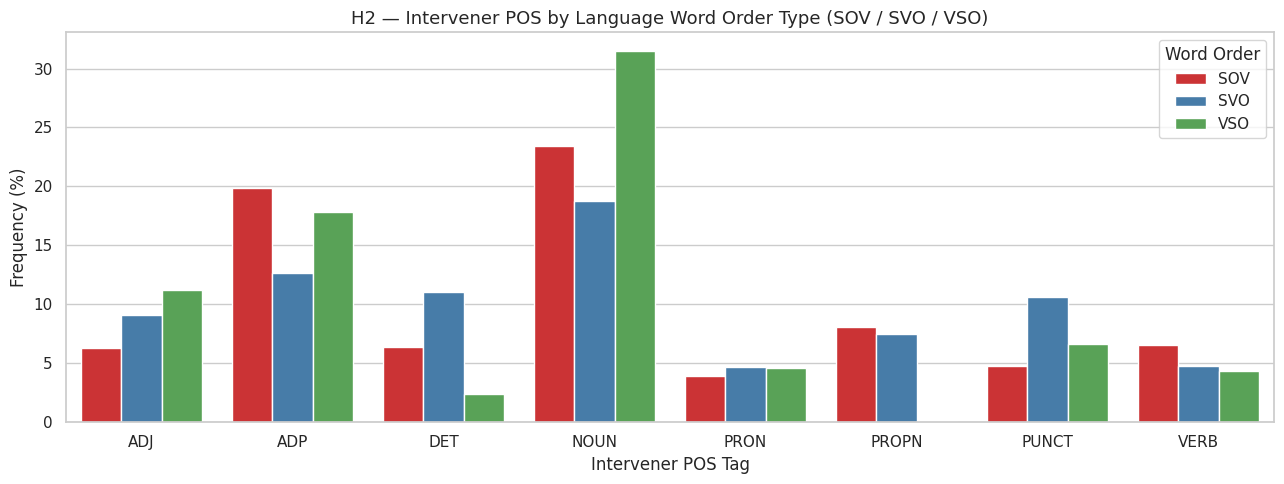

=== Direction ratio by word order group ===
  word_order   direction    count    percent
0        SOV   head-left   548338  34.488163
1        SOV  head-right  1041593  65.511837
2        SVO   head-left  2336798  65.914624
3        SVO  head-right  1208391  34.085376
4        VSO   head-left   632761  92.110580
5        VSO  head-right    54197   7.889420


In [ ]:
# Plot 6 — H2: Direction by Word-Order Typology ───
# Extending H2 to canonical word-order groups (SOV / SVO / VSO)
# tests whether the direction effect is mediated by language
# typology: SOV languages are expected to show a higher
# proportion of head-right arcs and corresponding differences
# in intervener POS composition.
pos_by_order = df.groupby(['word_order', 'intervener_upos']).size().reset_index(name='count')
pos_by_order['percent'] = pos_by_order.groupby('word_order')['count'].transform(
    lambda x: x / x.sum() * 100
)

top8 = df['intervener_upos'].value_counts().head(8).index.tolist()
plot_data = pos_by_order[pos_by_order['intervener_upos'].isin(top8)]

plt.figure(figsize=(13, 5))
sns.barplot(data=plot_data, x='intervener_upos', y='percent',
            hue='word_order', palette='Set1')
plt.title('H2 — Intervener POS by Language Word Order Type (SOV / SVO / VSO)', fontsize=13)
plt.xlabel('Intervener POS Tag')
plt.ylabel('Frequency (%)')
plt.legend(title='Word Order')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cgs410-project/plots/plot6_H2_typology.png', dpi=150)
plt.show()

# Direction ratio per word-order group: what % of deps are head-right?
# A higher head-right % in SOV languages would confirm that
# our direction variable tracks real typological differences.
dir_by_order = df.groupby(['word_order', 'direction']).size().reset_index(name='count')
dir_by_order['percent'] = dir_by_order.groupby('word_order')['count'].transform(
    lambda x: x / x.sum() * 100
)
print("=== Direction ratio by word order group ===")
print(dir_by_order.to_string())

/tmp/ipykernel_820/5181747.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['distance_bin'] = pd.Categorical(plot_data['distance_bin'],


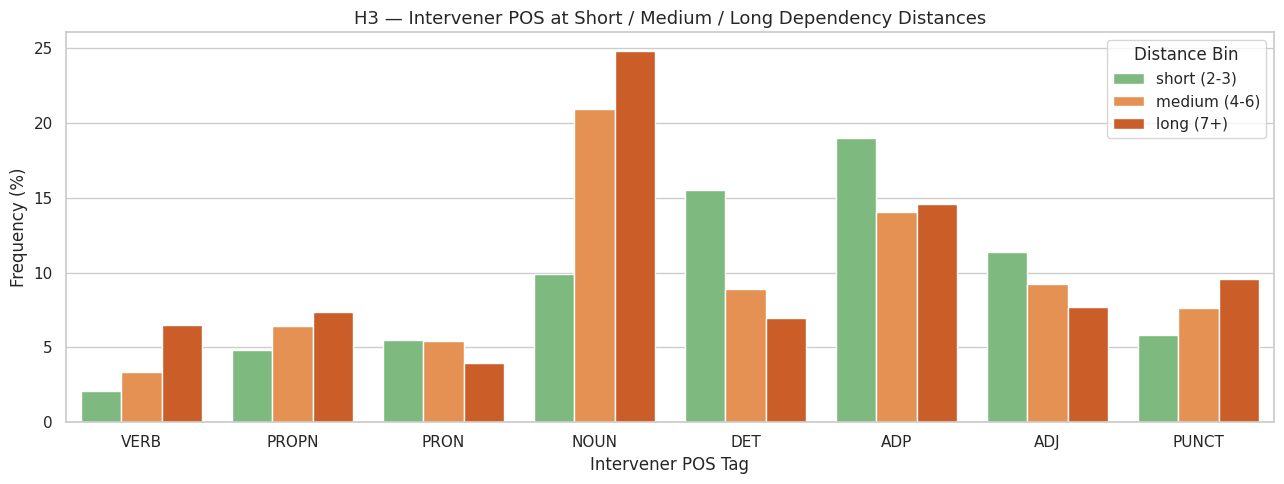

=== H3 Summary: % VERB and % DET at each distance bin ===
intervener_upos    ADP    DET   NOUN  VERB
distance_bin                              
short (2-3)      19.00  15.50   9.87  2.10
medium (4-6)     14.05   8.91  20.92  3.35
long (7+)        14.60   6.96  24.80  6.52


/tmp/ipykernel_820/5181747.py:37: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_h3 = plot_data[plot_data['intervener_upos'].isin(['VERB', 'DET', 'ADP', 'NOUN'])].pivot_table(


In [ ]:
# Plot 7 — H3: POS by Distance Bin (Bar) ──────────
# H3 predicts that short-distance dependencies are dominated by
# tight functional relations (DET, ADP modifying adjacent heads)
# while longer dependencies increasingly contain verbal and
# clausal material as embedded phrases expand.

# Bin order for plotting
bin_order = ['short (2-3)', 'medium (4-6)', 'long (7+)']

pos_by_bin = df.groupby(['distance_bin', 'intervener_upos']).size().reset_index(name='count')
pos_by_bin['percent'] = pos_by_bin.groupby('distance_bin')['count'].transform(
    lambda x: x / x.sum() * 100
)

top8 = df['intervener_upos'].value_counts().head(8).index.tolist()
plot_data = pos_by_bin[pos_by_bin['intervener_upos'].isin(top8)]

# Enforce the logical short → medium → long ordering on the x-axis
plot_data['distance_bin'] = pd.Categorical(plot_data['distance_bin'],
                                            categories=bin_order, ordered=True)
plot_data = plot_data.sort_values('distance_bin')

plt.figure(figsize=(13, 5))
sns.barplot(data=plot_data, x='intervener_upos', y='percent',
            hue='distance_bin', hue_order=bin_order,
            palette=['#74c476', '#fd8d3c', '#e6550d'])
plt.title('H3 — Intervener POS at Short / Medium / Long Dependency Distances', fontsize=13)
plt.xlabel('Intervener POS Tag')
plt.ylabel('Frequency (%)')
plt.legend(title='Distance Bin')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cgs410-project/plots/plot7_H3_distance_bins.png', dpi=150)
plt.show()

# Key numbers: VERB % and DET % at each distance bin
print("=== H3 Summary: % VERB and % DET at each distance bin ===")
pivot_h3 = plot_data[plot_data['intervener_upos'].isin(['VERB', 'DET', 'ADP', 'NOUN'])].pivot_table(
    index='distance_bin', columns='intervener_upos', values='percent'
).round(2)
print(pivot_h3.to_string())

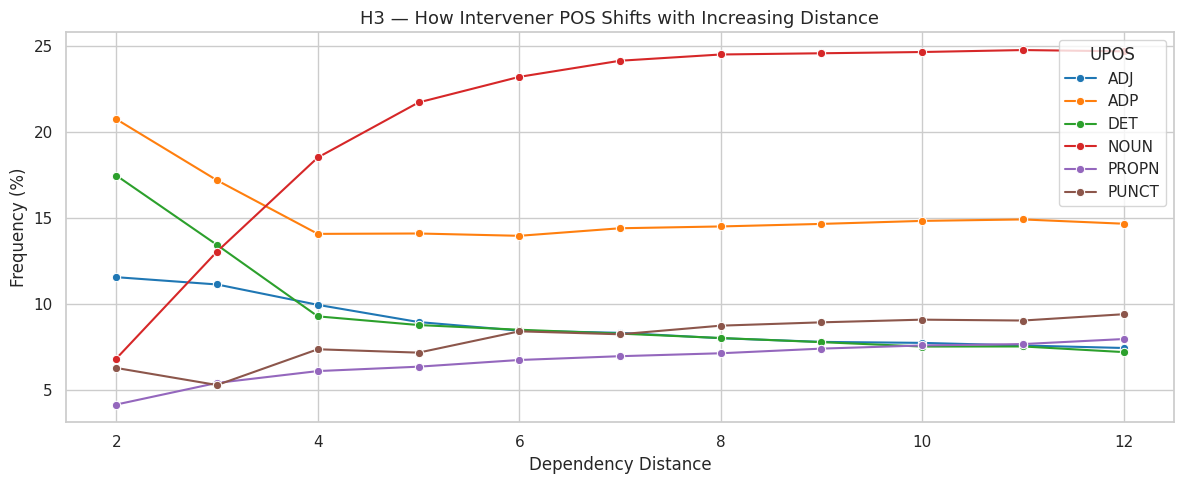

In [ ]:
# Plot 8 — H3: POS Shift with Raw Distance (Line) ──
# A continuous line plot (distances 2–12) shows *how* the POS
# composition shifts token by token rather than in coarse bins,
# making any gradient effects visible (e.g. monotonic rise of
# VERB with distance, decline of DET).

top6 = df['intervener_upos'].value_counts().head(6).index.tolist()

# Cap at distance 12 to avoid noisy tails from extremely rare
# very-long arcs that would distort the y-axis
dist_pos = (
    df[df['distance'] <= 12]
    .groupby(['distance', 'intervener_upos'])
    .size()
    .reset_index(name='count')
)
dist_pos['percent'] = dist_pos.groupby('distance')['count'].transform(
    lambda x: x / x.sum() * 100
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=dist_pos[dist_pos['intervener_upos'].isin(top6)],
             x='distance', y='percent', hue='intervener_upos',
             marker='o', palette='tab10')
plt.title('H3 — How Intervener POS Shifts with Increasing Distance', fontsize=13)
plt.xlabel('Dependency Distance')
plt.ylabel('Frequency (%)')
plt.legend(title='UPOS')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cgs410-project/plots/plot8_H3_line.png', dpi=150)
plt.show()

In [ ]:
# Conditional Distribution Table ───────────────────
# Compute P(intervener_upos | head_upos, direction, distance_bin)
# — the joint distribution conditioned on all three hypothesis
# variables simultaneously.  This table is saved for reference
# in the written report and for any follow-up modelling.

cond_dist = (
    df[df['head_upos'].isin(['VERB', 'NOUN', 'ADJ', 'ADP'])]
    .groupby(['head_upos', 'direction', 'distance_bin', 'intervener_upos'])
    .size()
    .reset_index(name='count')
)
cond_dist['P'] = cond_dist.groupby(['head_upos', 'direction', 'distance_bin'])['count'].transform(
    lambda x: x / x.sum() * 100
)

# Save full table
cond_dist.to_csv('/content/drive/MyDrive/cgs410-project/conditional_distribution.csv', index=False)

# Show a readable excerpt: VERB head, short distance
# These two queries represent the most common and theoretically
# interesting conditioning contexts for H1 and H2 combined.
print("=== P(intervener | VERB head, head-left, short distance) ===")
mask = (
    (cond_dist['head_upos'] == 'VERB') &
    (cond_dist['direction'] == 'head-left') &
    (cond_dist['distance_bin'] == 'short (2-3)')
)
print(cond_dist[mask].sort_values('P', ascending=False).head(8)[['intervener_upos', 'P']].to_string(index=False))

print("\n=== P(intervener | NOUN head, head-left, short distance) ===")
mask2 = (
    (cond_dist['head_upos'] == 'NOUN') &
    (cond_dist['direction'] == 'head-left') &
    (cond_dist['distance_bin'] == 'short (2-3)')
)
print(cond_dist[mask2].sort_values('P', ascending=False).head(8)[['intervener_upos', 'P']].to_string(index=False))

=== P(intervener | VERB head, head-left, short distance) ===
intervener_upos         P
            ADP 20.743717
            DET 16.604392
            AUX 15.045299
           NOUN  9.057685
            ADJ  7.728413
           PRON  7.136715
            ADV  5.773660
           VERB  3.499002

=== P(intervener | NOUN head, head-left, short distance) ===
intervener_upos         P
            ADP 33.466921
            DET 13.748433
            ADJ 12.702538
          PUNCT  9.959866
          CCONJ  9.139940
           NOUN  5.936131
           PRON  2.943341
            AUX  2.786371


In [ ]:
# Chi-Squared Significance Tests ───────────────────
# Basic chi-squared tests assess whether each predictor variable
# (head POS, direction, distance bin, language) is statistically
# independent of intervener POS.  All tests use the full dataset
# so power is not a concern; effect size (Cell 16) is the key
# metric for practical significance.
from scipy.stats import chi2_contingency

print("=" * 55)
print("H1 TEST — Does head type predict intervener POS?")
print("=" * 55)

# Contingency table: rows = head POS (VERB/NOUN), cols = intervener POS
h1_table = pd.crosstab(
    df[df['head_upos'].isin(['VERB', 'NOUN'])]['head_upos'],
    df[df['head_upos'].isin(['VERB', 'NOUN'])]['intervener_upos']
)
chi2, p, dof, _ = chi2_contingency(h1_table)
print(f"Chi² = {chi2:.2f},  df = {dof},  p = {p:.2e}")
print("→ Significant (p < 0.05)" if p < 0.05 else "→ Not significant")

print()
print("=" * 55)
print("H2 TEST — Does direction predict intervener POS?")
print("=" * 55)

# Contingency table: rows = direction, cols = intervener POS
h2_table = pd.crosstab(df['direction'], df['intervener_upos'])
chi2, p, dof, _ = chi2_contingency(h2_table)
print(f"Chi² = {chi2:.2f},  df = {dof},  p = {p:.2e}")
print("→ Significant (p < 0.05)" if p < 0.05 else "→ Not significant")

print()
print("=" * 55)
print("H3 TEST — Does distance bin predict intervener POS?")
print("=" * 55)

# Contingency table: rows = distance bin, cols = intervener POS
h3_table = pd.crosstab(df['distance_bin'], df['intervener_upos'])
chi2, p, dof, _ = chi2_contingency(h3_table)
print(f"Chi² = {chi2:.2f},  df = {dof},  p = {p:.2e}")
print("→ Significant (p < 0.05)" if p < 0.05 else "→ Not significant")

print()
print("=" * 55)
print("CROSS-LANGUAGE TEST — Does POS differ across languages?")
print("=" * 55)

# Contingency table: rows = language, cols = intervener POS
lang_table = pd.crosstab(df['language'], df['intervener_upos'])
chi2, p, dof, _ = chi2_contingency(lang_table)
print(f"Chi² = {chi2:.2f},  df = {dof},  p = {p:.2e}")
print("→ Significant (p < 0.05)" if p < 0.05 else "→ Not significant")

H1 TEST — Does head type predict intervener POS?
Chi² = 127163.21,  df = 16,  p = 0.00e+00
→ Significant (p < 0.05)

H2 TEST — Does direction predict intervener POS?
Chi² = 106751.24,  df = 16,  p = 0.00e+00
→ Significant (p < 0.05)

H3 TEST — Does distance bin predict intervener POS?
Chi² = 320850.29,  df = 32,  p = 0.00e+00
→ Significant (p < 0.05)

CROSS-LANGUAGE TEST — Does POS differ across languages?
Chi² = 2080336.67,  df = 176,  p = 0.00e+00
→ Significant (p < 0.05)


In [ ]:
# Final Summary Table per Language ─────────────────
# Aggregate per-language statistics that appear in the results
# section of the written report.  Sorted by average dependency
# distance (descending) to highlight which languages exhibit
# longer dependency arcs overall.

summary = df.groupby('language').agg(
    total_interveners = ('intervener_upos', 'count'),
    avg_distance      = ('distance', 'mean'),
    pct_head_right    = ('direction', lambda x: (x == 'head-right').mean() * 100),
    top_intervener    = ('intervener_upos', lambda x: x.value_counts().index[0]),
    pct_noun          = ('intervener_upos', lambda x: (x == 'NOUN').mean() * 100),
    pct_verb          = ('intervener_upos', lambda x: (x == 'VERB').mean() * 100),
    pct_det           = ('intervener_upos', lambda x: (x == 'DET').mean() * 100),
).round(2)
summary['word_order'] = summary.index.map(WORD_ORDER_GROUP)
summary = summary.sort_values('avg_distance', ascending=False)

print("=== FINAL SUMMARY TABLE ===\n")
print(summary.to_string())
summary.to_csv('/content/drive/MyDrive/cgs410-project/summary_table.csv')
print("\nSaved ✓")

=== FINAL SUMMARY TABLE ===

               total_interveners  avg_distance  pct_head_right top_intervener  pct_noun  pct_verb  pct_det word_order
language                                                                                                             
Arabic                    686958         37.20            7.89           NOUN     31.50      4.33     2.38        VSO
Spanish                   886298         16.62           22.66            ADP     13.46      3.50    19.35        SVO
Chinese                   282394         14.64           53.12           NOUN     28.68     10.61     1.02        SVO
Hindi                     680436         13.25           65.93            ADP     23.07      4.61     2.07        SOV
English                   455203         12.99           31.10           NOUN     15.46      5.13    11.09        SVO
German                    691166         12.57           44.46            DET     15.94      1.49    17.82        SVO
Japanese                  2

In [ ]:
# Cramér's V Effect Sizes ─────────────────────────
# Chi-squared is inflated by large N and cannot be compared
# across tests with different table dimensions.  Cramér's V
# normalises chi-squared to [0, 1] and is interpretable as:
#   < 0.10  → small / negligible effect
#   0.10–0.29 → medium effect
#   ≥ 0.30  → large effect
# (thresholds following Cohen 1988 adapted for contingency tables)

import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(contingency_table):
    """
    Compute Cramér's V effect size for a contingency table.

    Parameters
    ----------
    contingency_table : pd.DataFrame
        A cross-tabulation produced by pd.crosstab().

    Returns
    -------
    tuple : (chi2, p, dof, V)
        chi2 — test statistic
        p    — p-value
        dof  — degrees of freedom
        V    — Cramér's V (effect size, range 0–1)
    """
    chi2, p, dof, _ = chi2_contingency(contingency_table)
    n = contingency_table.values.sum()
    # k = min dimension − 1, used to bound V at 1 regardless of table shape
    k = min(contingency_table.shape) - 1
    v = np.sqrt(chi2 / (n * k))
    return chi2, p, dof, v

print("=" * 60)
print("H1 — Head type (VERB vs NOUN) → Intervener POS")
print("=" * 60)
h1_table = pd.crosstab(
    df[df['head_upos'].isin(['VERB', 'NOUN'])]['head_upos'],
    df[df['head_upos'].isin(['VERB', 'NOUN'])]['intervener_upos']
)
chi2, p, dof, v = cramers_v(h1_table)
print(f"Chi² = {chi2:.2f}, df = {dof}, p = {p:.2e}")
print(f"Cramér's V = {v:.4f}  → Effect size: {'small' if v < 0.1 else 'medium' if v < 0.3 else 'large'}")

print()
print("=" * 60)
print("H2 — Dependency direction → Intervener POS")
print("=" * 60)
h2_table = pd.crosstab(df['direction'], df['intervener_upos'])
chi2, p, dof, v = cramers_v(h2_table)
print(f"Chi² = {chi2:.2f}, df = {dof}, p = {p:.2e}")
print(f"Cramér's V = {v:.4f}  → Effect size: {'small' if v < 0.1 else 'medium' if v < 0.3 else 'large'}")

print()
print("=" * 60)
print("H3 — Distance bin → Intervener POS")
print("=" * 60)
h3_table = pd.crosstab(df['distance_bin'], df['intervener_upos'])
chi2, p, dof, v = cramers_v(h3_table)
print(f"Chi² = {chi2:.2f}, df = {dof}, p = {p:.2e}")
print(f"Cramér's V = {v:.4f}  → Effect size: {'small' if v < 0.1 else 'medium' if v < 0.3 else 'large'}")

print()
print("=" * 60)
print("CROSS-LANGUAGE — Language → Intervener POS")
print("=" * 60)
lang_table = pd.crosstab(df['language'], df['intervener_upos'])
chi2, p, dof, v = cramers_v(lang_table)
print(f"Chi² = {chi2:.2f}, df = {dof}, p = {p:.2e}")
print(f"Cramér's V = {v:.4f}  → Effect size: {'small' if v < 0.1 else 'medium' if v < 0.3 else 'large'}")

H1 — Head type (VERB vs NOUN) → Intervener POS
Chi² = 127163.21, df = 16, p = 0.00e+00
Cramér's V = 0.1613  → Effect size: medium

H2 — Dependency direction → Intervener POS
Chi² = 106751.24, df = 16, p = 0.00e+00
Cramér's V = 0.1354  → Effect size: medium

H3 — Distance bin → Intervener POS
Chi² = 320850.29, df = 32, p = 0.00e+00
Cramér's V = 0.1660  → Effect size: medium

CROSS-LANGUAGE — Language → Intervener POS
Chi² = 2080336.67, df = 176, p = 0.00e+00
Cramér's V = 0.1802  → Effect size: medium


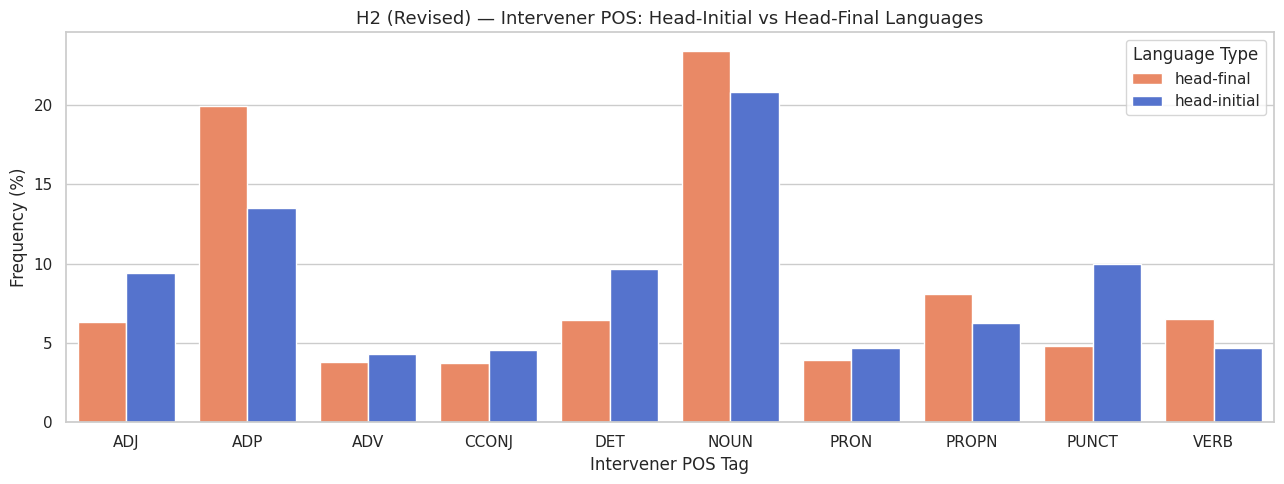

=== Intervener Class by Language Type ===
head_directionality intervener_class  count   percent
         head-final         pre-head 240619 15.133927
         head-final     right-branch 346758 21.809626
       head-initial         pre-head 927144 21.907179
       head-initial     right-branch 663116 15.668548


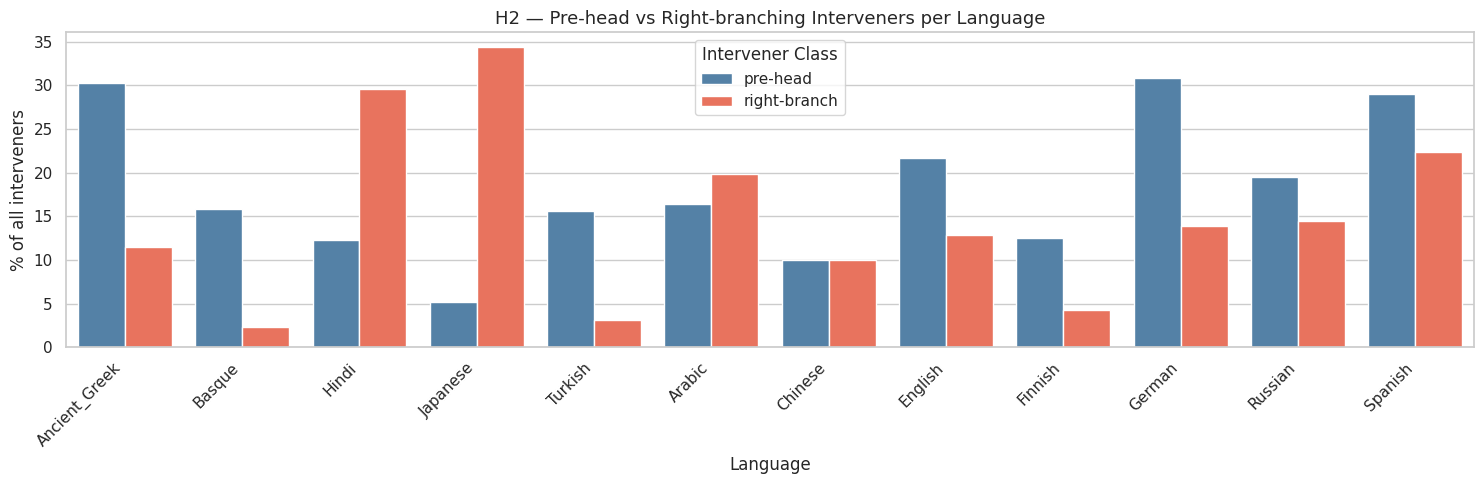


H2 REVISED — Language type (head-initial/final) → Intervener POS
Chi² = 174825.71, df = 16, p = 0.00e+00
Cramér's V = 0.1733  → Effect size: medium


In [ ]:
# Typological Analysis — Head-Initial vs Head-Final ─
# We reclassify languages along the head-directionality axis
# (orthogonal to but correlated with word order) to provide a
# cleaner test of H2.  Head-initial languages place the head
# before its dependents (English, Spanish, Arabic …); head-final
# languages do the reverse (Japanese, Turkish, Basque …).
# The prediction: head-final languages should show higher rates
# of pre-head modifier interveners (ADJ, DET, NUM) because
# modifiers precede the noun/verb head and therefore sit
# between the head and more distant dependents.

HEAD_DIRECTIONALITY = {
    'English':       'head-initial',
    'German':        'head-initial',
    'Spanish':       'head-initial',
    'Russian':       'head-initial',
    'Arabic':        'head-initial',
    'Finnish':       'head-initial',   # mixed but predominantly head-initial
    'Chinese':       'head-initial',
    'Hindi':         'head-final',
    'Turkish':       'head-final',
    'Japanese':      'head-final',
    'Basque':        'head-final',
    'Ancient_Greek': 'head-final',     # predominantly head-final / free but SOV tendency
}

df['head_directionality'] = df['language'].map(HEAD_DIRECTIONALITY)

# ── Plot 9: Intervener POS by Head-Initial vs Head-Final ──────
pos_by_typology = df.groupby(['head_directionality', 'intervener_upos']).size().reset_index(name='count')
pos_by_typology['percent'] = pos_by_typology.groupby('head_directionality')['count'].transform(
    lambda x: x / x.sum() * 100
)

top10 = df['intervener_upos'].value_counts().head(10).index.tolist()
plot_data = pos_by_typology[pos_by_typology['intervener_upos'].isin(top10)]

plt.figure(figsize=(13, 5))
sns.barplot(
    data=plot_data,
    x='intervener_upos', y='percent',
    hue='head_directionality',
    palette={'head-initial': 'royalblue', 'head-final': 'coral'}
)
plt.title('H2 (Revised) — Intervener POS: Head-Initial vs Head-Final Languages', fontsize=13)
plt.xlabel('Intervener POS Tag')
plt.ylabel('Frequency (%)')
plt.legend(title='Language Type')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cgs410-project/plots/plot9_H2_typology_revised.png', dpi=150)
plt.show()

# ── Intervener Class Analysis ─────────────────────────────────
# To quantify the contrast more precisely, we collapse the full
# POS tagset into two theory-motivated classes:
#   right-branch — ADP and SCONJ: functional heads that
#                  introduce post-head complements / adjuncts
#   pre-head     — ADJ, DET, NUM: pre-nominal modifiers that
#                  precede the noun in head-final languages
# 'other' covers everything else (NOUN, VERB, PUNCT, …).

df['intervener_class'] = df['intervener_upos'].map({
    'ADP': 'right-branch',
    'SCONJ': 'right-branch',
    'ADJ': 'pre-head',
    'DET': 'pre-head',
    'NUM': 'pre-head',
}).fillna('other')

class_by_type = df.groupby(['head_directionality', 'intervener_class']).size().reset_index(name='count')
class_by_type['percent'] = class_by_type.groupby('head_directionality')['count'].transform(
    lambda x: x / x.sum() * 100
)

print("=== Intervener Class by Language Type ===")
print(class_by_type[class_by_type['intervener_class'] != 'other'].to_string(index=False))

# Plot 10: Pre-head vs Right-branching per Language ─────────
# Sorting by head_directionality groups head-initial languages
# on the left and head-final on the right, making the typological
# contrast immediately visible without extra annotation.

lang_class = df.groupby(['language', 'head_directionality', 'intervener_class']).size().reset_index(name='count')
lang_class['percent'] = lang_class.groupby(['language'])['count'].transform(
    lambda x: x / x.sum() * 100
)

lang_pct = lang_class[lang_class['intervener_class'].isin(['right-branch', 'pre-head'])].copy()
lang_pct = lang_pct.sort_values(['head_directionality', 'language'])

plt.figure(figsize=(15, 5))
sns.barplot(
    data=lang_pct,
    x='language', y='percent',
    hue='intervener_class',
    palette={'right-branch': 'tomato', 'pre-head': 'steelblue'}
)
plt.title('H2 — Pre-head vs Right-branching Interveners per Language', fontsize=13)
plt.xlabel('Language')
plt.ylabel('% of all interveners')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Intervener Class')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cgs410-project/plots/plot10_H2_per_language_class.png', dpi=150)
plt.show()

# ── H2 Revised — Chi-squared + Cramér's V ────────────────────
# This test directly measures whether language type
# (head-initial vs head-final) predicts intervener POS,
# using the same cramers_v helper defined in Cell 17.

print()
print("=" * 60)
print("H2 REVISED — Language type (head-initial/final) → Intervener POS")
print("=" * 60)
h2_type_table = pd.crosstab(df['head_directionality'], df['intervener_upos'])
chi2, p, dof, v = cramers_v(h2_type_table)
print(f"Chi² = {chi2:.2f}, df = {dof}, p = {p:.2e}")
print(f"Cramér's V = {v:.4f}  → Effect size: {'small' if v < 0.1 else 'medium' if v < 0.3 else 'large'}")